# Multicollinearity in Linear Regression

## Objective

The goal of this notebook is to understand how multicollinearity affects Linear Regression models.

We will create highly correlated features, detect multicollinearity using correlation and VIF, and observe how it affects regression coefficients and model interpretation.

## What is Multicollinearity?

Multicollinearity happens when independent variables are highly correlated with each other.

In this situation, the regression model struggles to understand the individual effect of correlated features because they contain very similar information.

## Why is it a Problem?

Multicollinearity usually does not affect prediction performance too much, but it can make regression coefficients unstable and unreliable.

Small changes in the data can cause large changes in coefficient values, making feature interpretation difficult.

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
# load dataset
data = pd.read_csv('/content/drive/My Drive/Advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


## Correlation Analysis

Let's check the correlation between our original features. If the correlation is high (typically > 0.5 or < -0.5), it might indicate multicollinearity.

In [115]:
data[['TV', 'Radio', 'Newspaper']].corr()

,TV,Radio,Newspaper
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Newspaper,0.056648,0.354104,1.000000


Since all correlation values are below 0.5, there is no strong multicollinearity present in our original dataset.

## Variance Inflation Factor (VIF)

VIF measures how strongly a feature is related to other independent variables.

Higher VIF values indicate stronger multicollinearity.

General interpretation:

- VIF ≈ 1 → No multicollinearity
- VIF > 5 → Moderate multicollinearity
- VIF > 10 → Strong multicollinearity

In [116]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# select only independent variables
X = data[['TV', 'Radio', 'Newspaper']]

# add constant
X_constant = sm.add_constant(X)

# create VIF DataFrame
vif_data = pd.DataFrame()
vif_data['features'] = X_constant.columns

vif_data['VIF'] = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]

print(vif_data)

    features       VIF
0      const  6.848900
1         TV  1.004611
2      Radio  1.144952
3  Newspaper  1.145187


As we can see from the results above, the VIF for `TV`, `Radio`, and `Newspaper` are all approximately **1**. 

Because a VIF of 1 indicates no correlation between that independent variable and the others, this statistically proves that our original dataset does **not** have multicollinearity.

In [117]:
# shuffle and split data
X_no_multicorr = data[['TV', 'Radio', 'Newspaper']]
y_no_multicorr = data['Sales']

# split in train and test
from sklearn.model_selection import train_test_split
x_train_no_multicorr, x_test_no_multicorr, y_train_no_multicorr, y_test_no_multicorr = train_test_split(X_no_multicorr, y_no_multicorr, 
                                                                                                        test_size=0.3, random_state=42)
# fit model
from sklearn.linear_model import LinearRegression
lr_no_multicorr = LinearRegression()
lr_no_multicorr.fit(x_train_no_multicorr, y_train_no_multicorr)

LinearRegression()

In [118]:
y_pred_no_multicorr = lr_no_multicorr.predict(x_test_no_multicorr)

In [119]:

from sklearn.metrics import r2_score
print(f"R2 Score (No Multicollinearity): {r2_score(y_test_no_multicorr, y_pred_no_multicorr)}")

R2 Score (No Multicollinearity): 0.8609466508230368


## Creating Artificial Multicollinearity

The original Advertising dataset does not contain strong multicollinearity.

To study its effects, a new feature highly correlated with the TV feature was created artificially.

In [120]:
df = data.copy()

# intentionally create a new feature ('Theatre') that is highly correlated with 'TV'
df['Theatre'] = df['TV'] * 0.95 + np.random.normal(0, 5, len(df))

df

,TV,Radio,Newspaper,Sales,Theatre
0,230.1,37.8,69.2,22.1,219.985727
1,44.5,39.3,45.1,10.4,39.550033
2,17.2,45.9,69.3,9.3,18.749158
3,151.5,41.3,58.5,18.5,141.425106
4,180.8,10.8,58.4,12.9,173.225886
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,38.333810
196,94.2,4.9,8.1,9.7,94.671163
197,177.0,9.3,6.4,12.8,166.271753
198,283.6,42.0,66.2,25.5,269.175659


In [121]:
df[['TV', 'Radio', 'Newspaper', 'Theatre']].corr()

,TV,Radio,Newspaper,Theatre
TV,1.000000,0.054809,0.056648,0.998244
Radio,0.054809,1.000000,0.354104,0.053611
Newspaper,0.056648,0.354104,1.000000,0.057677
Theatre,0.998244,0.053611,0.057677,1.000000


We can now clearly see a strong correlation between `TV` and `Theatre` (0.997), which is well above the 0.5 threshold.

In [122]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# select only independent variables
X = df[['TV', 'Radio', 'Newspaper', 'Theatre']]

# add constant
X_constant = sm.add_constant(X)

# create VIF DataFrame
vif_data = pd.DataFrame()
vif_data['features'] = X_constant.columns

vif_data['VIF'] = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]

print(vif_data)

    features         VIF
0      const    6.946044
1         TV  285.302280
2      Radio    1.145793
3  Newspaper    1.146048
4    Theatre  285.301227


The VIF scores for both `TV` and `Theatre` are extremely high (> 238). A VIF greater than 10 statistically proves strong multicollinearity between these features.

In [123]:
# run a simulation 10 times to observe coefficient instability under multicollinearity

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

results = []

for i in range(10):
    df_multi = df.copy()

    df_multi['TV_dup'] = (
        df_multi['TV'] * 0.99 +
        np.random.normal(0, 1, len(df_multi))
    )

    X = df_multi[['TV', 'Radio', 'Newspaper', 'TV_dup']]
    y = df_multi['Sales']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    lr = LinearRegression()

    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)

    results.append([
        i + 1,
        lr.coef_[0],   # TV
        lr.coef_[3],   # TV_dup
        r2_score(y_test, y_pred)
    ])

coef_df = pd.DataFrame(
    results,
    columns=['Iteration', 'TV_Coefficient', 'TV_dup_Coefficient', 'R2']
)

coef_df

,Iteration,TV_Coefficient,TV_dup_Coefficient,R2
0,1,0.107577,-0.063426,0.900083
1,2,-0.176464,0.223253,0.901557
2,3,0.139430,-0.095635,0.902051
3,4,0.217703,-0.174998,0.899052
4,5,-0.163778,0.210174,0.897651
5,6,-0.423532,0.473112,0.885623
6,7,-0.092759,0.138883,0.900159
7,8,-0.101365,0.147654,0.893465
8,9,0.034602,0.010240,0.899759
9,10,-0.164228,0.211115,0.904767


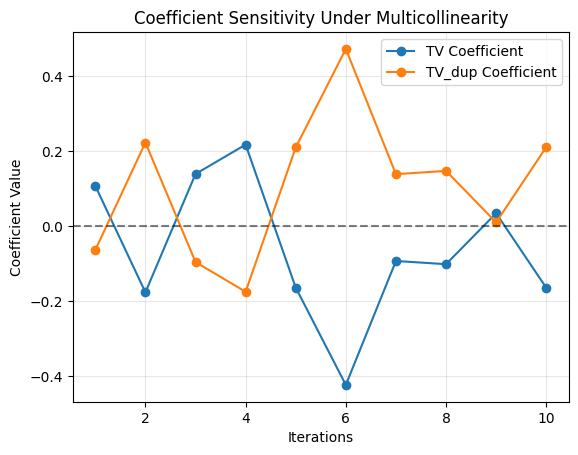

In [ ]:
# let's visualize coefficient sensitivity under multicollinearity
plt.plot(
    coef_df['Iteration'],
    coef_df['TV_Coefficient'],
    marker='o',
    label='TV Coefficient'
)

plt.plot(
    coef_df['Iteration'],
    coef_df['TV_dup_Coefficient'],
    marker='o',
    label='TV_dup Coefficient'
)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Iterations")
plt.ylabel("Coefficient Value")
plt.title("Coefficient Sensitivity Under Multicollinearity")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The coefficient values fluctuate across different iterations

In some iterations, the TV coefficient even becomes negative while the correlated duplicate feature receives a large positive coefficient. This demonstrates that multicollinearity makes coefficient estimation highly unstable and sensitive to small data changes.

Although prediction performance remains relatively stable, interpreting the individual effect of highly correlated features becomes unreliable.

Basically model is saying: "I cannot confidently decide which correlated variable deserves the weight."

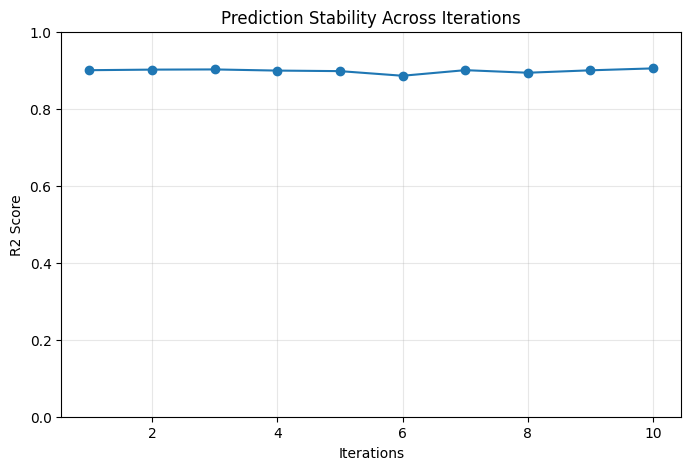

In [125]:
# plot the R2 score across all 10 simulation runs to check for prediction stability

plt.figure(figsize=(8,5))

plt.plot(
    coef_df['Iteration'],
    coef_df['R2'],
    marker='o'
)

plt.xlabel("Iterations")
plt.ylabel("R2 Score")

plt.title("Prediction Stability Across Iterations")
plt.ylim(0,1)
plt.grid(alpha=0.3)

plt.show()

Despite the wildly unstable coefficients seen above, this plot proves that the model's overall predictive accuracy ($R^2$ score) remains stable. Multicollinearity harms interpretability, not necessarily predictive power.

# Final Insight

This notebook shows that multicollinearity mainly affects coefficient stability and feature interpretation rather than prediction accuracy.

Even though the model performance remained almost the same, the coefficients of highly correlated features became unstable and sensitive to small changes in the data.

This makes it difficult to interpret the true effect of correlated variables in a Linear Regression model.